# 1: Exploratory Data Analysis
# KKBox Churn Analysis

**Project:** KKBox Subscription Churn Analysis + Automated Insight Pipeline  
**Dataset:** [KKBox Music Streaming Churn — Kaggle](https://www.kaggle.com/c/kkbox-churn-prediction-challenge/data)  
**Author:** Santiago Dueñas 

---

## Objective

Understand the structure, quality, and behavioral patterns across all four KKBox tables before moving into SQL cohort analysis and feature engineering. Key questions:

1. What does the churn label distribution look like?
2. What member demographics are present?
3. What transaction patterns exist (payment methods, renewal behavior, plan types)?
4. What listening behaviors differentiate churned vs. retained users?
5. Are there data quality issues to address before modeling?

## Tables
| Table | Description | Approx. Rows |
|-------|-------------|-------------|
| `members_v3.csv` | User demographics & registration info | ~6.7M |
| `transactions_v2.csv` | Subscription transactions | ~21.5M |
| `user_logs_v2.csv` | Daily listening behavior logs | ~30M |
| `train_v2.csv` | Churn labels | ~970K |

---
## 0. Setup & Imports

In [2]:
#Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Chart styling

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'times new roman',
    'axes.titlesize':   15,
    'axes.labelsize':   13,
})
PALETTE_CHURN = {0: '#09CEF6', 1: '#F44336'}  # blue = retained, red = churned

#Paths 

DATA_DIR = Path('../../data')

print(f'Data directory: {DATA_DIR.resolve()}')

Data directory: C:\Users\Santiago\Documents\Data Analysis\KKbox Project\data


---
## 1. Load Datasets

> `user_logs_v2.csv` (~30M rows) and `transactions_v2.csv` (~21.5M rows) take a few minutes to load. Sampling options are provided, for quick iteration set SAMPLE_TXT = True and SAMPLE_LOGS = True

In [3]:
# Load members data

print('Loading members_v3.csv...')
members = pd.read_csv(
    DATA_DIR / 'members_v3.csv',
    dtype={
        'msno':             'str',
        'city':             'Int8',
        'bd':               'Int16',
        'gender':           'str',
        'registered_via':   'Int8',
        'registration_init_time': 'str'
    }
)
print(f'  members: {members.shape[0]:,} rows × {members.shape[1]} cols')

#Load churn labels 

print('Loading train_v2.csv...')
train = pd.read_csv(
    DATA_DIR / 'train_v2.csv',
    dtype={'msno': 'str', 'is_churn': 'Int8'}
)
print(f'  train:   {train.shape[0]:,} rows × {train.shape[1]} cols')

Loading members_v3.csv...
  members: 6,769,473 rows × 6 cols
Loading train_v2.csv...
  train:   970,960 rows × 2 cols


In [4]:
# Load transactions data
# Set SAMPLE_TXN = True for faster iteration; False for full load

SAMPLE_TXN = True
N_TXN_SAMPLE = 1_000_000

print('Loading transactions_v2.csv...')
txn_dtype = {
    'msno':                 'str',
    'payment_method_id':    'Int8',
    'payment_plan_days':    'Int16',
    'plan_list_price':      'Int32',
    'actual_amount_paid':   'Int32',
    'is_auto_renew':        'Int8',
    'transaction_date':     'str',
    'membership_expire_date': 'str',
    'is_cancel':            'Int8'
}
if SAMPLE_TXN:
    transactions = pd.read_csv(DATA_DIR / 'transactions_v2.csv', dtype=txn_dtype, nrows=N_TXN_SAMPLE)
    print(f'  transactions (SAMPLE): {transactions.shape[0]:,} rows')
else:
    transactions = pd.read_csv(DATA_DIR / 'transactions_v2.csv', dtype=txn_dtype)
    print(f'  transactions: {transactions.shape[0]:,} rows × {transactions.shape[1]} cols')

Loading transactions_v2.csv...
  transactions (SAMPLE): 1,000,000 rows


In [5]:
#Load user logs

SAMPLE_LOGS = True
N_LOG_SAMPLE = 1_000_000

print('Loading user_logs_v2.csv...')
log_dtype = {
    'msno':           'str',
    'date':           'str',
    'num_25':         'Int32',
    'num_50':         'Int32',
    'num_75':         'Int32',
    'num_985':        'Int32',
    'num_100':        'Int32',
    'num_unq':        'Int32',
    'total_secs':     'float32'
}
if SAMPLE_LOGS:
    user_logs = pd.read_csv(DATA_DIR / 'user_logs_v2.csv', dtype=log_dtype, nrows=N_LOG_SAMPLE)
    print(f'  user_logs (SAMPLE): {user_logs.shape[0]:,} rows')
else:
    user_logs = pd.read_csv(DATA_DIR / 'user_logs_v2.csv', dtype=log_dtype)
    print(f'  user_logs: {user_logs.shape[0]:,} rows × {user_logs.shape[1]} cols')

print('\nAll files loaded.')

Loading user_logs_v2.csv...
  user_logs (SAMPLE): 1,000,000 rows

All files loaded.


---
## 2. Schema Overview

In [6]:
def df_profile(df, name):
    """Print a compact data profile: shape, dtypes, null rates, sample."""
    print(f"\n{'='*120}")
    print(f"  Table: {name}")
    print(f"  Rows x Cols: {df.shape}")
    
    null_df = pd.DataFrame({
        'dtype':     df.dtypes.astype(str),
        'nulls':     df.isnull().sum(),
        'null_pct':  (df.isnull().mean() * 100).round(2),
        'n_unique':  df.nunique()
    })
    display(null_df)
    print("\nSample rows:")
    display(df.head(3))

df_profile(members,      'members_v3')
df_profile(train,        'train_v2')
df_profile(transactions, 'transactions_v2')
df_profile(user_logs,    'user_logs_v2')


  Table: members_v3
  Rows x Cols: (6769473, 6)


,dtype,nulls,null_pct,n_unique
msno,object,0,0.00,6769473
city,Int8,0,0.00,21
bd,Int16,0,0.00,386
gender,object,4429505,65.43,2
registered_via,Int8,0,0.00,18
registration_init_time,object,0,0.00,4782



Sample rows:


,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915



  Table: train_v2
  Rows x Cols: (970960, 2)


...

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,20170131,20170504,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,20150809,20190412,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,20170303,20170422,0



  Table: user_logs_v2
  Rows x Cols: (1000000, 9)


,dtype,nulls,null_pct,n_unique
msno,object,0,0.0,591758
date,object,0,0.0,31
num_25,Int32,0,0.0,363
num_50,Int32,0,0.0,181
num_75,Int32,0,0.0,96
num_985,Int32,0,0.0,220
num_100,Int32,0,0.0,590
num_unq,Int32,0,0.0,432
total_secs,float32,0,0.0,924155



Sample rows:


,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,20170331,8,4,0,1,21,18,6309.272949
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,2390.698975
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,20170331,52,3,5,3,84,110,23203.337891


---
## 3. Churn Labels (`train_v2.csv`)

The label: `is_churn = 1` means the user did **not** renew within 30 days of subscription expiry.

Churn Rate Distribution
-----------------------------------
  0 (Retained):  883,630  (91.0%)
  1 (Churned ):   87,330  (9.0%)


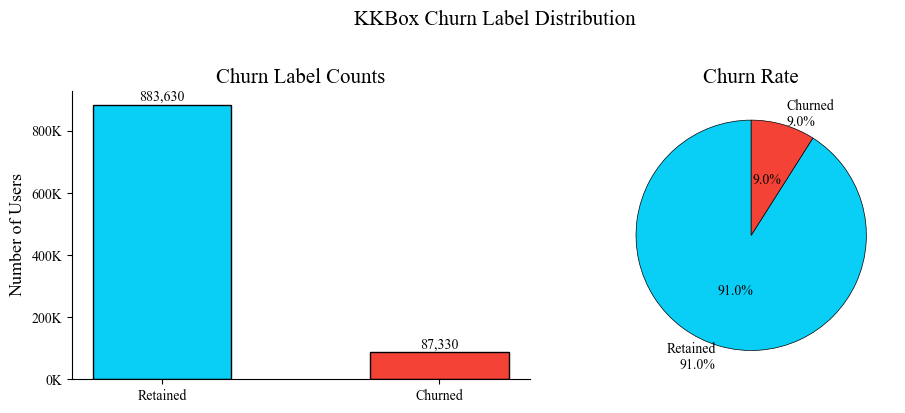


Key takeaway: Class imbalance, noted this for modeling strategy.


In [7]:
churn_counts = train['is_churn'].value_counts().sort_index()
churn_pct    = train['is_churn'].value_counts(normalize=True).sort_index() * 100

print('Churn Rate Distribution')
print('-' * 35)
for label, count in churn_counts.items():
    tag = 'Churned' if label == 1 else 'Retained'
    print(f'  {label} ({tag:8s}): {count:>8,}  ({churn_pct[label]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = axes[0].bar(
    ['Retained', 'Churned'],
    churn_counts.values,
    color=[PALETTE_CHURN[0], PALETTE_CHURN[1]],
    width=0.5, edgecolor='black'
)
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 3000,
        f'{bar.get_height():,}',
        ha='center', va='bottom', fontsize=10
    )
axes[0].set_title('Churn Label Counts')
axes[0].set_ylabel('Number of Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

# Pie chart
axes[1].pie(
    churn_counts.values,
    labels=[f'Retained\n{churn_pct[0]:.1f}%', f'Churned\n{churn_pct[1]:.1f}%'],
    colors=[PALETTE_CHURN[0], PALETTE_CHURN[1]],
    startangle=90, autopct='%1.1f%%', pctdistance=0.5,
    wedgeprops={'linewidth': 0.5, 'edgecolor': 'black'}
)
axes[1].set_title('Churn Rate')

plt.suptitle(('KKBox Churn Label Distribution'), fontsize=15, y=1.02)
plt.tight_layout()

#remove comment to save charts
#plt.savefig('../../data/fig_01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nKey takeaway: Class imbalance, noted this for modeling strategy.')

---
## 4. Members (`members_v3.csv`)

### 4.1 Parse & Clean Dates

In [ ]:
members['registration_init_time'] = pd.to_datetime(
    members['registration_init_time'], format='%Y%m%d', errors='coerce'
)

# date range
print('Registration date range:')
print(f"  Min: {members['registration_init_time'].min().date()}")
print(f"  Max: {members['registration_init_time'].max().date()}")
print(f"  Nulls: {members['registration_init_time'].isnull().sum():,}")

Registration date range:
  Min: 2004-03-26
  Max: 2017-04-29
  Nulls: 0


### 4.2 Age (`bd` field)

> The `bd` column is the the age the user provides, some noise is expected.

Raw bd (age) statistics:
count    6769473.0
mean      9.795794
std        17.9259
min        -7168.0
25%            0.0
50%            0.0
75%           21.0
max         2016.0
Name: bd, dtype: Float64

Zeros:     4,540,215
Negatives: 274
> 100:     5,377

Reasonable ages (1–100): 2,223,607 / 6,769,473 (32.8%)


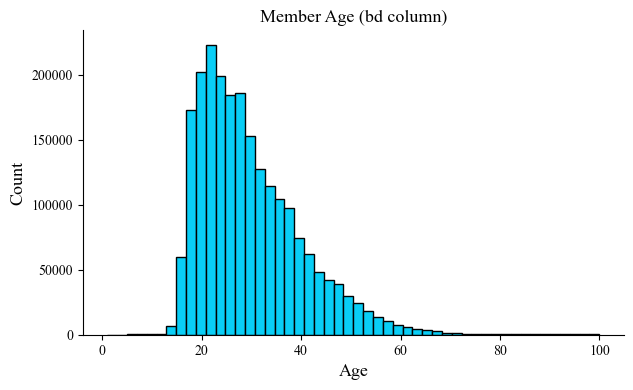

In [9]:
print('Raw bd (age) statistics:')
print(members['bd'].describe())
print(f"\nZeros:     {(members['bd'] == 0).sum():,}")
print(f"Negatives: {(members['bd'] < 0).sum():,}")
print(f"> 100:     {(members['bd'] > 100).sum():,}")

# Flag reasonable ages (1–100)

reasonable_age = members[(members['bd'] >= 1) & (members['bd'] <= 100)]['bd']
print(f"\nReasonable ages (1–100): {len(reasonable_age):,} / {len(members):,} ({len(reasonable_age)/len(members)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw (all values)

# axes[0].hist(members['bd'].dropna(), bins=100, color='#90CAF9', edgecolor='black')
# axes[0].set_title('Raw Age Distribution (all values)')
# axes[0].set_xlabel('bd (age)')
# axes[0].set_ylabel('Count')

# Cleaned

axes[1].hist(reasonable_age, bins=50, color='#09CEF6', edgecolor='black')
axes[1].set_title('Reasonable Age Distribution (1–100)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')

fig.delaxes(axes[0]) # Remove the raw age distribution plot to focus on the cleaned version

plt.title('Member Age (bd column)', fontsize=13)
plt.tight_layout()

#comment can be removed to save charts
#plt.savefig('../../data/fig_02_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Gender

Gender distribution:
gender
NaN       4429505
male      1195355
female    1144613
Name: count, dtype: int64

Null / not provided: 4,429,505 (65.4%)


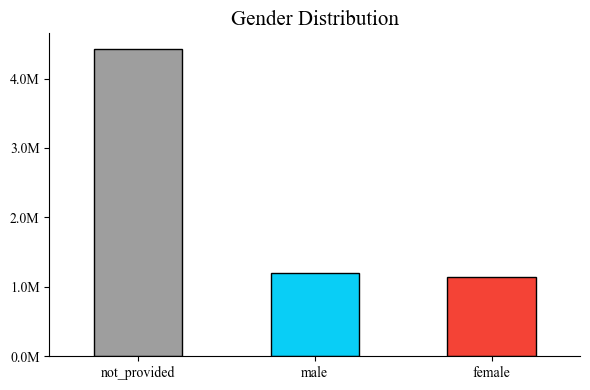

In [13]:
gender_counts = members['gender'].value_counts(dropna=False)
print('Gender distribution:')
print(gender_counts)
print(f"\nNull / not provided: {members['gender'].isnull().sum():,} ({members['gender'].isnull().mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
gender_plot = members['gender'].value_counts(dropna=False).rename({np.nan: 'not_provided'})
colors = ['#9E9E9E', '#09CEF6', '#F44336']
gender_plot.plot(kind='bar', ax=ax, color=colors[:len(gender_plot)], edgecolor='black', rot=0)
ax.set_title('Gender Distribution')
ax.set_xlabel('')
#ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

### 4.4 City & Registration Channel

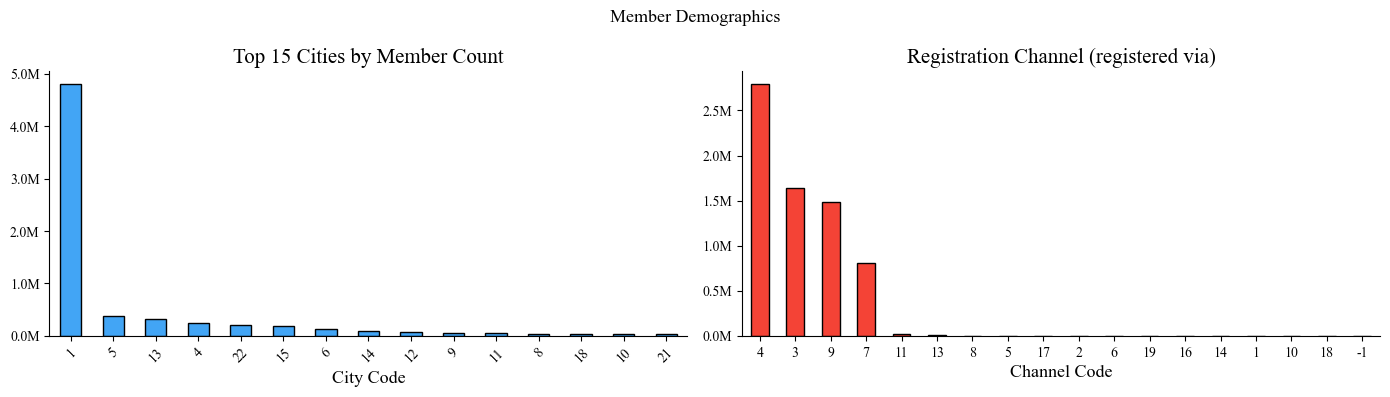

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# City distribution

city_counts = members['city'].value_counts().head(15)
city_counts.plot(kind='bar', ax=axes[0], color='#42A5F5', edgecolor='black', rot=45)
axes[0].set_title('Top 15 Cities by Member Count')
axes[0].set_xlabel('City Code')
#axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Registration channel

reg_counts = members['registered_via'].value_counts()
reg_counts.plot(kind='bar', ax=axes[1], color='#F44336', edgecolor='black', rot=0)
axes[1].set_title('Registration Channel (registered via)')
axes[1].set_xlabel('Channel Code')
#axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.suptitle('Member Demographics', fontsize=13)
plt.tight_layout()
#plt.savefig('../../data/fig_03_member_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Registration Cohort Over Time

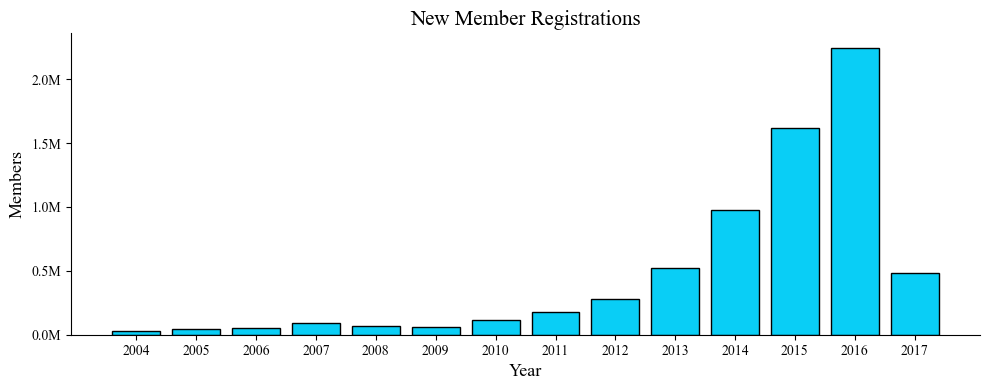

In [22]:
members['reg_year'] = members['registration_init_time'].dt.year
members['reg_month'] = members['registration_init_time'].dt.to_period('M')

reg_by_year = members['reg_year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(reg_by_year.index.astype(str), reg_by_year.values, color='#09CEF6', edgecolor='black')
ax.set_title('New Member Registrations')
ax.set_xlabel('Year')
ax.set_ylabel('Members')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
#plt.savefig('../../data/fig_04_registration_cohorts.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Transactions (`transactions_v2.csv`)

### 5.1 Parse Dates

In [23]:
transactions['transaction_date']      = pd.to_datetime(transactions['transaction_date'],      format='%Y%m%d', errors='coerce')
transactions['membership_expire_date'] = pd.to_datetime(transactions['membership_expire_date'], format='%Y%m%d', errors='coerce')

print('Transaction date range:')
print(f"  Transaction:  {transactions['transaction_date'].min().date()} → {transactions['transaction_date'].max().date()}")
print(f"  Expiry:       {transactions['membership_expire_date'].min().date()} → {transactions['membership_expire_date'].max().date()}")

Transaction date range:
  Transaction:  2015-01-01 → 2017-03-31
  Expiry:       2016-04-20 → 2036-10-15


### 5.2 Payment Plan Days Distribution

Payment plan days — top values:
payment_plan_days
0       1515
1        480
3          7
7       8481
10       289
14        55
21         7
30    851249
31         4
35        21
45        31
60      2180
70        33
80        31
90     13455
Name: count, dtype: Int64


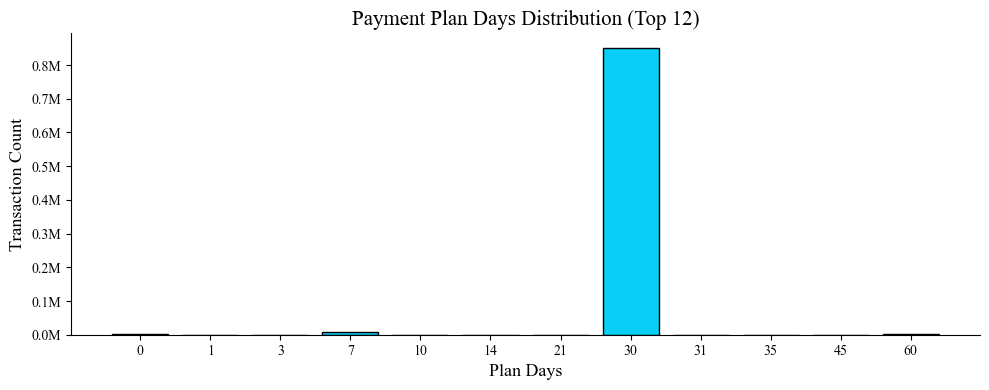

In [24]:
plan_counts = transactions['payment_plan_days'].value_counts().sort_index()
print('Payment plan days — top values:')
print(plan_counts.head(15))

fig, ax = plt.subplots(figsize=(10, 4))
top_plans = plan_counts.head(12)
ax.bar(top_plans.index.astype(str), top_plans.values, color='#09CEF6', edgecolor='black')
ax.set_title('Payment Plan Days Distribution (Top 12)')
ax.set_xlabel('Plan Days')
ax.set_ylabel('Transaction Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
#plt.savefig('../../data/fig_05_plan_days.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Auto-Renew & Cancellation Rates

Auto-renew rate:   78.5%
Cancellation rate: 2.5%


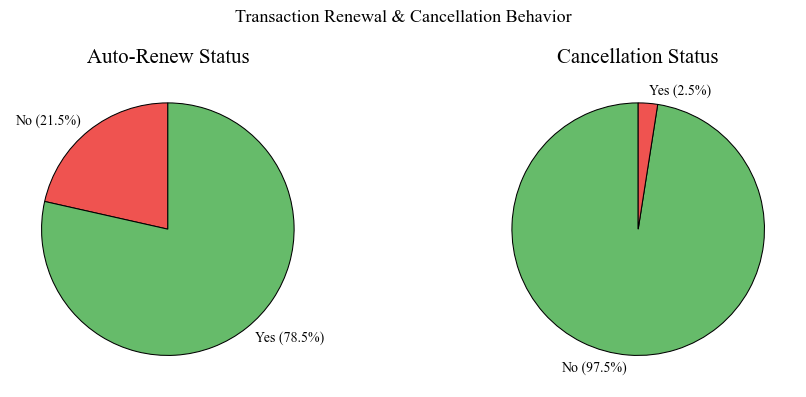

In [26]:
auto_renew_rate = transactions['is_auto_renew'].mean() * 100
cancel_rate     = transactions['is_cancel'].mean() * 100

print(f'Auto-renew rate:   {auto_renew_rate:.1f}%')
print(f'Cancellation rate: {cancel_rate:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, title, colors in [
    (axes[0], 'is_auto_renew', 'Auto-Renew Status', ['#EF5350', '#66BB6A']),
    (axes[1], 'is_cancel',     'Cancellation Status',['#66BB6A', '#EF5350']),
]:
    vc = transactions[col].value_counts().sort_index()
    ax.pie(
        vc.values,
        labels=[f'No ({vc.iloc[0]/len(transactions)*100:.1f}%)',
                f'Yes ({vc.iloc[1]/len(transactions)*100:.1f}%)'] if len(vc) == 2 else vc.index.astype(str),
        colors=colors[:len(vc)],
        startangle=90,
        wedgeprops={'linewidth': 0.75, 'edgecolor': 'black'}
    )
    ax.set_title(title)

plt.suptitle('Transaction Renewal & Cancellation Behavior', fontsize=13)
plt.tight_layout()
#plt.savefig('../../data/fig_06_autorenew_cancel.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Actual Amount Paid Distribution

Actual amount paid statistics:
count     1000000.0
mean     281.243679
std      435.307366
min             0.0
25%            99.0
50%           149.0
75%           149.0
max          2000.0
Name: actual_amount_paid, dtype: Float64

Zero-payment transactions: 15,009
Discount (paid < list):    6,715


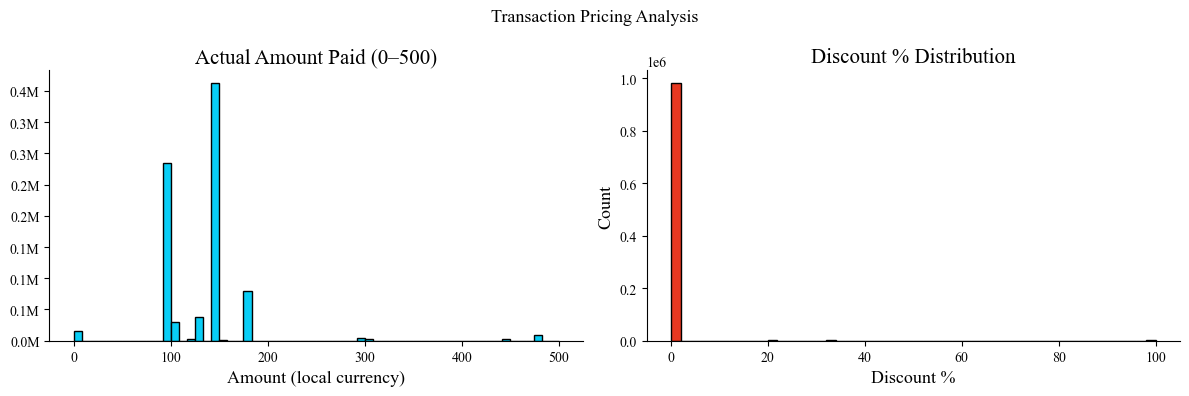

Zero-payment transactions: 1.50%


In [72]:
print('Actual amount paid statistics:')
print(transactions['actual_amount_paid'].describe())
print(f"\nZero-payment transactions: {(transactions['actual_amount_paid'] == 0).sum():,}")
print(f"Discount (paid < list):    {(transactions['actual_amount_paid'] < transactions['plan_list_price']).sum():,}")

# Discount rate
transactions['discount_pct'] = np.where(
    transactions['plan_list_price'] > 0,
    (1 - transactions['actual_amount_paid'] / transactions['plan_list_price']) * 100,
    np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Amount paid (cap at 500 for visualization)
amt_data = transactions[transactions['actual_amount_paid'].between(0, 500)]['actual_amount_paid']
axes[0].hist(amt_data, bins=60, color='#09CEF6', edgecolor='black')
axes[0].set_title('Actual Amount Paid (0–500)')
axes[0].set_xlabel('Amount (local currency)')
#
# axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Discount %
disc_data = transactions[transactions['discount_pct'].between(0, 100)]['discount_pct']
axes[1].hist(disc_data, bins=50, color="#E63821", edgecolor='black')
axes[1].set_title('Discount % Distribution')
axes[1].set_xlabel('Discount %')
axes[1].set_ylabel('Count')

plt.suptitle('Transaction Pricing Analysis', fontsize=13)
plt.tight_layout()
#plt.savefig('../../data/fig_07_transaction_pricing.png', dpi=150, bbox_inches='tight')
plt.show()

zero_pct = (transactions['actual_amount_paid'] == 0).mean() * 100
print(f"Zero-payment transactions: {zero_pct:.2f}%")

### 5.5 Transaction Volume Over Time

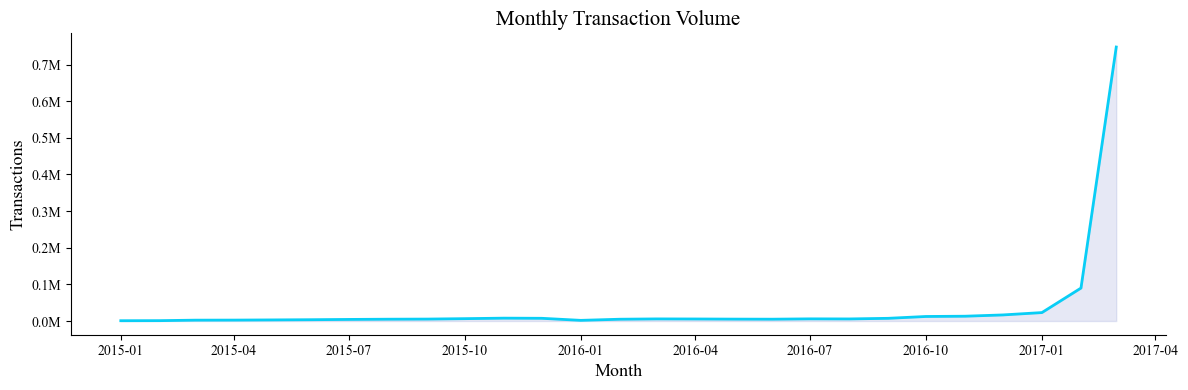

In [30]:
txn_monthly = (
    transactions
    .dropna(subset=['transaction_date'])
    .assign(month=lambda df: df['transaction_date'].dt.to_period('M'))
    .groupby('month')
    .size()
    .reset_index(name='txn_count')
)
txn_monthly['month_dt'] = txn_monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(txn_monthly['month_dt'], txn_monthly['txn_count'], color='#09CEF6', linewidth=2)
ax.fill_between(txn_monthly['month_dt'], txn_monthly['txn_count'], alpha=0.15, color='#5C6BC0')
ax.set_title('Monthly Transaction Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
#plt.savefig('../../data/fig_08_txn_volume_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Transactions Per User (Engagement Proxy)

Transactions per user:
count    868536.000000
mean          1.151363
std           0.977617
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         150.000000
dtype: float64


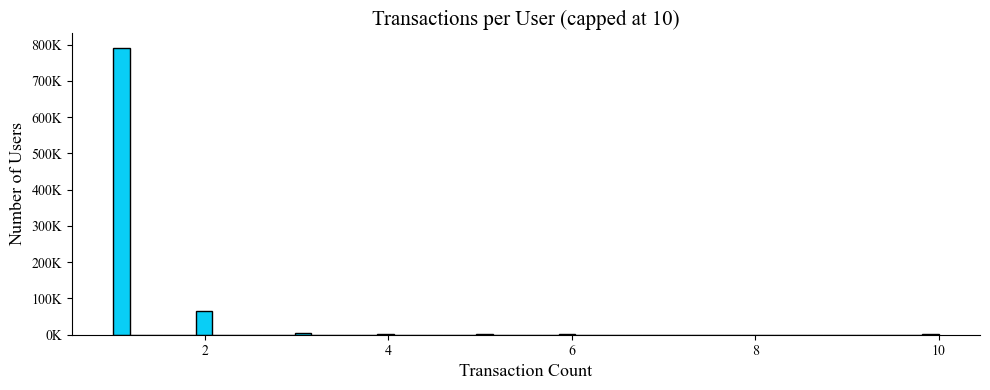

In [33]:
txn_per_user = transactions.groupby('msno').size()
print('Transactions per user:')
print(txn_per_user.describe())

fig, ax = plt.subplots(figsize=(10, 4))
# Cap at 10 for readability
ax.hist(txn_per_user.clip(upper=10), bins=50, color='#09CEF6', edgecolor='black')
ax.set_title('Transactions per User (capped at 10)')
ax.set_xlabel('Transaction Count')
ax.set_ylabel('Number of Users')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.show()

---
## 6. User Logs (`user_logs_v2.csv`)

Each row = one user's listening activity on one day.

| Column | Description |
|--------|-------------|
| `num_25` | Songs played < 25% of duration |
| `num_50` | Songs played 25%–50% |
| `num_75` | Songs played 50%–75% |
| `num_985` | Songs played 75%–98.5% |
| `num_100` | Songs played ≥ 98.5% (completed) |
| `num_unq` | Unique songs played |
| `total_secs` | Total listening seconds |

### 6.1 Parse Dates & Basic Profile

In [34]:
user_logs['date'] = pd.to_datetime(user_logs['date'], format='%Y%m%d', errors='coerce')

print('Log date range:')
print(f"  Min: {user_logs['date'].min().date()}")
print(f"  Max: {user_logs['date'].max().date()}")
print(f"  Total log rows: {len(user_logs):,}")
print(f"  Unique users:   {user_logs['msno'].nunique():,}")

print('\nListening metrics summary:')
listen_cols = ['num_25','num_50','num_75','num_985','num_100','num_unq','total_secs']
display(user_logs[listen_cols].describe().round(2))

Log date range:
  Min: 2017-03-01
  Max: 2017-03-31
  Total log rows: 1,000,000
  Unique users:   591,758

Listening metrics summary:


,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
count,1000000.0,1000000.0,1000000.0,1000000.0,1000000.0,1000000.0,1000000.00
mean,6.2,1.51,0.94,1.08,30.3,29.07,7911.61
std,12.97,3.95,1.91,3.59,39.84,32.04,9641.56
min,0.0,0.0,0.0,0.0,0.0,1.0,0.02
25%,0.0,0.0,0.0,0.0,7.0,8.0,1967.85
50%,2.0,1.0,0.0,0.0,17.0,19.0,4598.79
75%,7.0,2.0,1.0,1.0,37.0,38.0,9855.99
max,2101.0,558.0,241.0,957.0,2120.0,877.0,515927.53


### 6.2 Daily Total Listening Time

In [44]:
print(user_logs['date'].min(), '→', user_logs['date'].max())
print(f"Unique dates: {user_logs['date'].nunique()}")

2017-03-01 00:00:00 → 2017-03-31 00:00:00
Unique dates: 31


In [42]:
user_logs['date'] = pd.to_datetime(user_logs['date'], format='%Y%m%d', errors='coerce')

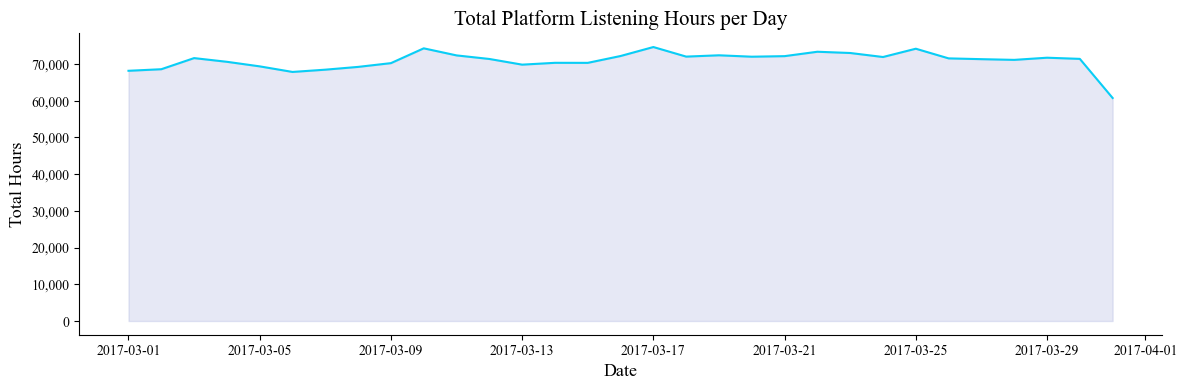

In [43]:

daily_listening = (
    user_logs
    .groupby('date')['total_secs']
    .sum()
    .reset_index()
    .rename(columns={'total_secs': 'total_hours'})
)
daily_listening = (
    user_logs
    .groupby('date')['total_secs']
    .sum()
    .reset_index()
)
daily_listening['total_hours'] = daily_listening['total_secs'] / 3600

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_listening['date'], daily_listening['total_hours'], color='#09CEF6', linewidth=1.5)
ax.fill_between(daily_listening['date'], daily_listening['total_hours'], alpha=0.15, color='#5C6BC0')
ax.set_title('Total Platform Listening Hours per Day')
ax.set_xlabel('Date')
ax.set_ylabel('Total Hours')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

### 6.3 Listening Completion Rate

Completion rate = `num_100 / (num_25 + num_50 + num_75 + num_985 + num_100)`. High completion indicates engaged listeners.

Completion rate (per user-day):
count    1000000.000000
mean           0.720640
std            0.262346
min            0.000000
25%            0.566667
50%            0.794118
75%            0.937500
max            1.000000
Name: completion_rate, dtype: float64


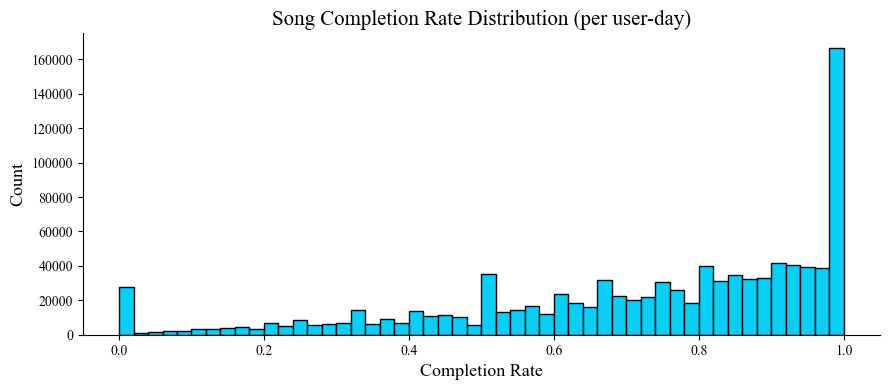

In [46]:
user_logs['total_plays'] = (
    user_logs['num_25'] + user_logs['num_50'] +
    user_logs['num_75'] + user_logs['num_985'] + user_logs['num_100']
)
user_logs['completion_rate'] = np.where(
    user_logs['total_plays'] > 0,
    user_logs['num_100'] / user_logs['total_plays'],
    np.nan
)

print('Completion rate (per user-day):')
print(user_logs['completion_rate'].describe())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(user_logs['completion_rate'].dropna(), bins=50, color='#09CEF6', edgecolor='black')
ax.set_title('Song Completion Rate Distribution (per user-day)')
ax.set_xlabel('Completion Rate')
ax.set_ylabel('Count')
plt.tight_layout()
#plt.savefig('../../data/fig_10_completion_rate.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Per-User Aggregate Listening Profile

In [47]:
user_agg = user_logs.groupby('msno').agg(
    log_days        = ('date',           'count'),
    first_log       = ('date',           'min'),
    last_log        = ('date',           'max'),
    avg_total_secs  = ('total_secs',     'mean'),
    total_secs_sum  = ('total_secs',     'sum'),
    avg_num_unq     = ('num_unq',        'mean'),
    avg_completion  = ('completion_rate','mean'),
    avg_total_plays = ('total_plays',    'mean'),
).reset_index()

user_agg['avg_daily_hours'] = user_agg['avg_total_secs'] / 3600

print(f'Users with log data: {len(user_agg):,}')
print('\nPer-user aggregate stats:')
display(user_agg[['log_days','avg_daily_hours','avg_num_unq','avg_completion']].describe().round(3))


Users with log data: 591,758

Per-user aggregate stats:


,log_days,avg_daily_hours,avg_num_unq,avg_completion
count,591758.000,591758.000,591758.0,591758.000
mean,1.690,2.078,27.722,0.714
std,0.925,2.416,28.659,0.249
min,1.000,0.000,1.0,0.000
25%,1.000,0.606,9.0,0.571
50%,1.000,1.303,19.0,0.772
75%,2.000,2.587,36.0,0.917
max,9.000,143.313,821.0,1.000


---
## 7. Cross-Table Analysis — Churn vs. Behavior

Merge all tables to compare behavioral patterns between churned and retained users.

### 7.1 Merge Strategy

In [ ]:
# Start from labeled users (train), merge outward

df = train.merge(members,  on='msno', how='left')
df = df.merge(user_agg,    on='msno', how='left')

# Latest transaction per user

latest_txn = (
    transactions
    .sort_values('transaction_date')
    .groupby('msno')
    .last()
    .reset_index()
    [['msno','payment_plan_days','plan_list_price','actual_amount_paid',
      'is_auto_renew','is_cancel','transaction_date','membership_expire_date']]
    .rename(columns=lambda c: f'last_{c}' if c != 'msno' else c)
)

df = df.merge(latest_txn, on='msno', how='left')

print(f'Merged dataset: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Coverage — user logs:       {df["log_days"].notna().sum():,} / {len(df):,}')
print(f'Coverage — last transaction: {df["last_transaction_date"].notna().sum():,} / {len(df):,}')

Merged dataset: 970,960 rows × 25 cols
Coverage — user logs:       433,356 / 970,960
Coverage — last transaction: 678,477 / 970,960


### 7.2 Listening Activity: Churned vs. Retained

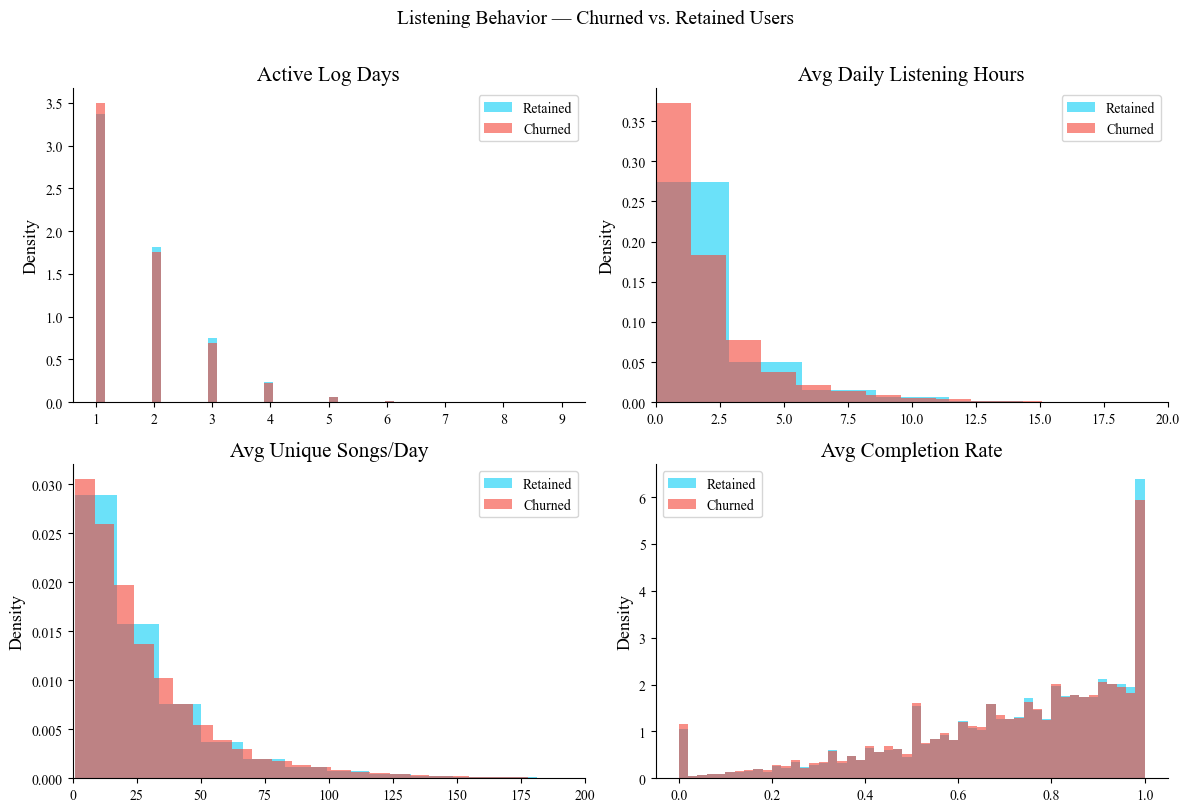

In [54]:
metrics = [
    ('log_days',        'Active Log Days',              None),
    ('avg_daily_hours', 'Avg Daily Listening Hours',    20),
    ('avg_num_unq',     'Avg Unique Songs/Day',         200),
    ('avg_completion',  'Avg Completion Rate',          None),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, label, xlim) in zip(axes, metrics):
    for churn_val, color in PALETTE_CHURN.items():
        data = df[df['is_churn'] == churn_val][col].dropna()
        tag = 'Churned' if churn_val == 1 else 'Retained'
        ax.hist(data, bins=50, alpha=0.6, color=color, label=tag, density=True)
    ax.set_title(label)
    ax.set_ylabel('Density')
    if xlim:
        ax.set_xlim(0, xlim)
    ax.legend()

plt.suptitle('Listening Behavior — Churned vs. Retained Users', fontsize=14, y=1.01)
plt.tight_layout()
#plt.savefig('../../data/fig_11_churn_vs_listening.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Summary Statistics: Churned vs. Retained

In [71]:
compare_cols = [
    'log_days', 'avg_daily_hours', 'avg_num_unq',
    'avg_completion', 'last_is_auto_renew', 'last_is_cancel'
]

summary = (
    df.groupby('is_churn')[compare_cols]
    .apply(lambda g: g.apply(pd.to_numeric, errors='coerce').mean())
    .T
    .rename(columns={0: 'Retained (mean)', 1: 'Churned (mean)'})
    .assign(delta_pct=lambda x: ((x['Churned (mean)'] - x['Retained (mean)']) / x['Retained (mean)'] * 100).round(1))
)

print('Mean feature values \n\nChurned vs. Retained')
print('(delta_pct = % difference, churned relative to retained)')
display(summary.round(4))

Mean feature values 

Churned vs. Retained
(delta_pct = % difference, churned relative to retained)


is_churn,Retained (mean),Churned (mean),delta_pct
log_days,1.7002,1.6657,-2.0
avg_daily_hours,2.0499,2.0970,2.3
avg_num_unq,27.1828,28.3181,4.2
avg_completion,0.7197,0.7117,-1.1
last_is_auto_renew,0.9353,0.5948,-36.4
last_is_cancel,0.0078,0.2794,3502.4


### 7.4 Churn Rate by Member Demographics

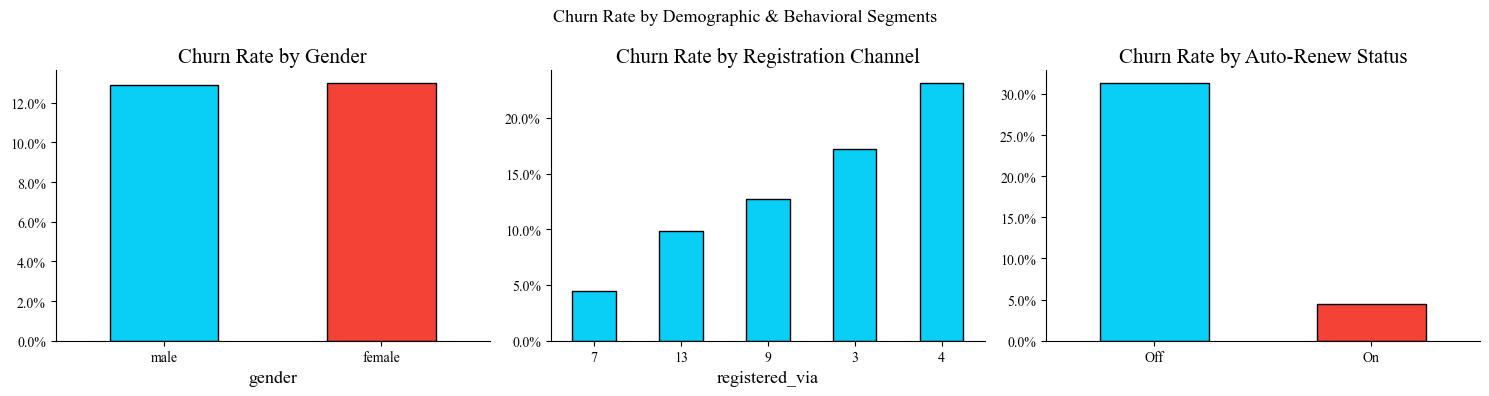

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# By gender
gender_churn = df.groupby('gender')['is_churn'].mean().sort_values()
PALETTE_CHURN = {0: '#09CEF6', 1: '#F44336'}  # blue = retained, red = churned
gender_churn.plot(kind='bar', ax=axes[0], color=[PALETTE_CHURN[0], PALETTE_CHURN[1]], edgecolor='black', rot=0)
axes[0].set_title('Churn Rate by Gender')
#axes[0].set_ylabel('Churn Rate')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))

# By registration channel
reg_churn = df.groupby('registered_via')['is_churn'].mean().sort_values()
reg_churn.plot(kind='bar', ax=axes[1], color=[PALETTE_CHURN[0]], edgecolor='black', rot=0)
axes[1].set_title('Churn Rate by Registration Channel')
#axes[1].set_ylabel('Churn Rate')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))

# By auto-renew status (latest transaction)
ar_churn = df.groupby('last_is_auto_renew')['is_churn'].mean().sort_index()
labels = [f'{"Off" if k == 0 else "On"}' for k in ar_churn.index]
ar_churn.index = labels
ar_churn.plot(kind='bar', ax=axes[2], color=[PALETTE_CHURN[0], PALETTE_CHURN[1]], edgecolor='black', rot=0)
axes[2].set_title('Churn Rate by Auto-Renew Status')
#axes[2].set_ylabel('Churn Rate')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x*100:.1f}%'))

plt.suptitle('Churn Rate by Demographic & Behavioral Segments', fontsize=13)
plt.tight_layout()
#plt.savefig('../../data/fig_12_churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Churn Rate by Payment Plan Length

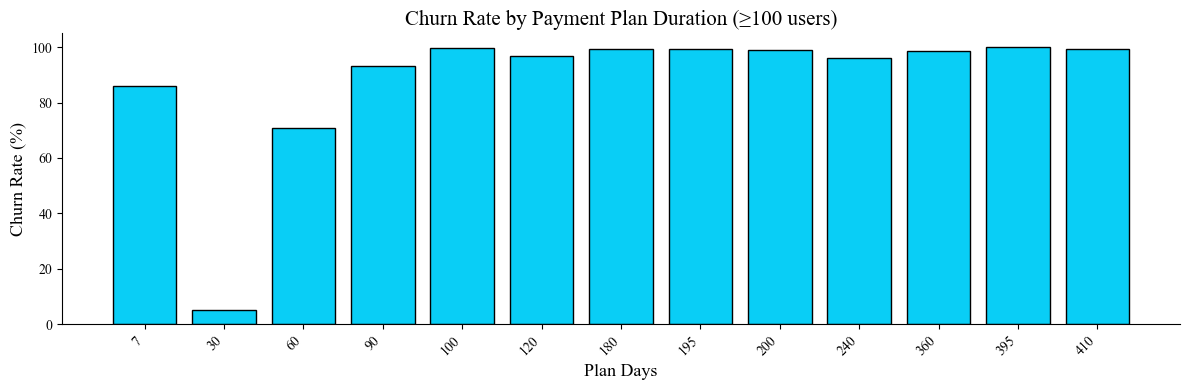

In [65]:
plan_churn = (
    df.groupby('last_payment_plan_days')
    .agg(churn_rate=('is_churn','mean'), n_users=('is_churn','count'))
    .reset_index()
    .query('n_users >= 100')  # filter out rare plan types
    .sort_values('last_payment_plan_days')
)

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(
    plan_churn['last_payment_plan_days'].astype(str),
    plan_churn['churn_rate'] * 100,
    color=[PALETTE_CHURN[0]], edgecolor='black'
)
ax.set_title('Churn Rate by Payment Plan Duration (≥100 users)')
ax.set_xlabel('Plan Days')
ax.set_ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.savefig('../../data/fig_13_churn_by_plan.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Data Quality Summary

In [67]:
print("DATA QUALITY NOTES")
print("=" * 120)

print("\n[members_v3]")
print(f"  bd (age):  {(members['bd'] == 0).sum():,} zeros, {(members['bd'] < 0).sum():,} negatives, {(members['bd'] > 100).sum():,} > 100")
print(f"  gender:    {members['gender'].isnull().mean()*100:.1f}% null")
print(f"  city:      {members['city'].isnull().mean()*100:.1f}% null")

print("\n[transactions_v2]")
print(f"  txn_date null:    {transactions['transaction_date'].isnull().sum():,}")
print(f"  expire_date null: {transactions['membership_expire_date'].isnull().sum():,}")
print(f"  zero payments:    {(transactions['actual_amount_paid'] == 0).sum():,}")

print("\n[user_logs_v2]")
print(f"  date null:        {user_logs['date'].isnull().sum():,}")
print(f"  total_secs zeros: {(user_logs['total_secs'] == 0).sum():,}")
print(f"  total_secs neg:   {(user_logs['total_secs'] < 0).sum():,}")

print("\n[train_v2]")
print(f"  msno null:  {train['msno'].isnull().sum()}")
print(f"  label null: {train['is_churn'].isnull().sum()}")

print("\n[Cross-table coverage]")
labeled_users = set(train['msno'])
log_users     = set(user_logs['msno'])
txn_users     = set(transactions['msno'])
member_users  = set(members['msno'])
print(f"  Labeled users with log data:     {len(labeled_users & log_users):,} / {len(labeled_users):,} ({len(labeled_users & log_users)/len(labeled_users)*100:.1f}%)")
print(f"  Labeled users with transactions: {len(labeled_users & txn_users):,} / {len(labeled_users):,} ({len(labeled_users & txn_users)/len(labeled_users)*100:.1f}%)")
print(f"  Labeled users with member data:  {len(labeled_users & member_users):,} / {len(labeled_users):,} ({len(labeled_users & member_users)/len(labeled_users)*100:.1f}%)")

DATA QUALITY NOTES

[members_v3]
  bd (age):  4,540,215 zeros, 274 negatives, 5,377 > 100
  gender:    65.4% null
  city:      0.0% null

[transactions_v2]
  txn_date null:    0
  expire_date null: 0
  zero payments:    15,009

[user_logs_v2]
  date null:        0
  total_secs zeros: 0
  total_secs neg:   0

[train_v2]
  msno null:  0
  label null: 0

[Cross-table coverage]
  Labeled users with log data:     433,356 / 970,960 (44.6%)
  Labeled users with transactions: 678,477 / 970,960 (69.9%)
  Labeled users with member data:  860,967 / 970,960 (88.7%)


---
## 9. EDA Summary & Next Steps

### Key Findings

**Churn Rate**
- Overall churn rate is approximately 9.0% with class imbalance present, will require stratified sampling or class weighting in models.

**Member Demographics**
- Age (`bd`) is heavily noisy majority of data points are zero or outliers. Only ~32.8% of users have plausible ages (1–100). Will require imputation or exclusion.
- Gender is ~65.4% missing, use as a feature cautiously.
- Registration channel shows clear variation; some channels correlate with higher churn.

**Transactions**
- Dominant plan length is 30 days, the other longer plans (90, 180, 365) show different churn behavior.
- Auto-renew OFF strongly predicts churn can consider this is likely the single most important feature.
- Zero-payment transactions exist (~1.5%); need to understand if these are trials or billing errors.

**User Listening Behavior**
- Churned users have fewer active log days and lower average listening hours which is consistent with disengagement.
- Completion rate of songs may be a useful engagement signal.
- Large spread in per-user log coverage, some users have very few log entries.

### Data Quality Actions Before Modeling
1. **Age**: Flag unrealistic values; optionally impute median by gender/city or drop column.
2. **Gender**: Keep as feature with `unknown` category for nulls.
3. **Log coverage**: Users with zero logs need explicit handling (impute 0s or create a `has_logs` flag).
4. **Transaction history**: Some labeled users may lack recent transactions preferable to use last-known values.

### Next Notebooks
| Notebook | Description |
|----------|-------------|
| `02_sql_cohort_analysis.ipynb` | PostgreSQL-based cohort retention, monthly churn rates, window functions |
| `03_feature_engineering.ipynb` | Behavioral features: listening decay, session drop-off, payment lapse |
| `04_churn_model.ipynb` | Logistic regression + random forest, AUC evaluation, feature importance |
| `05_automated_brief.ipynb` | AI-powered monthly churn brief via Anthropic API |

In [ ]:
# Save the merged labeled dataset for use in downstream notebooks

SAVE_MERGED = True
if SAVE_MERGED:
    out_path = DATA_DIR / 'df_labeled_merged.parquet'
    df.to_parquet(out_path, index=False)
    print(f'Saved merged labeled dataset → {out_path}')
    print(f'Shape: {df.shape}')